In [1]:
import pandas as pd
import matplotlib
import seaborn as sns
import sklearn
import joblib

print("Analytics libraries are ready")

Analytics libraries are ready


In [2]:
import seaborn as sns

titanic = sns.load_dataset("titanic")

titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
titanic.shape

(891, 15)

In [4]:
titanic.isnull().sum()


survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [5]:
titanic_clean = titanic.copy()

# Drop deck because most values are missing
titanic_clean = titanic_clean.drop(columns=["deck"])

# Fill numerical missing values with median
titanic_clean["age"] = titanic_clean["age"].fillna(
    titanic_clean["age"].median()
)

# Fill categorical missing values with mode
titanic_clean["embarked"] = titanic_clean["embarked"].fillna(
    titanic_clean["embarked"].mode()[0]
)

titanic_clean["embark_town"] = titanic_clean["embark_town"].fillna(
    titanic_clean["embark_town"].mode()[0]
)

titanic_clean.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

In [7]:
titanic_clean.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


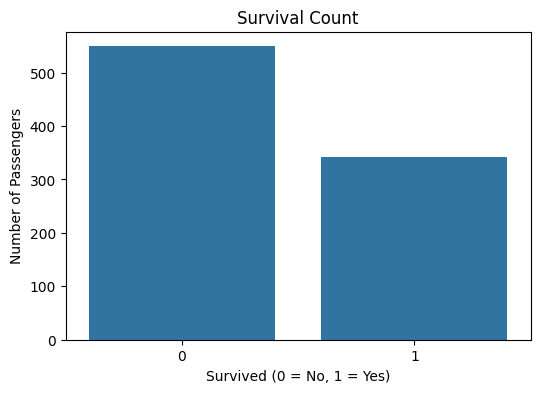

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.countplot(
    data=titanic_clean,
    x="survived"
)

plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.show()

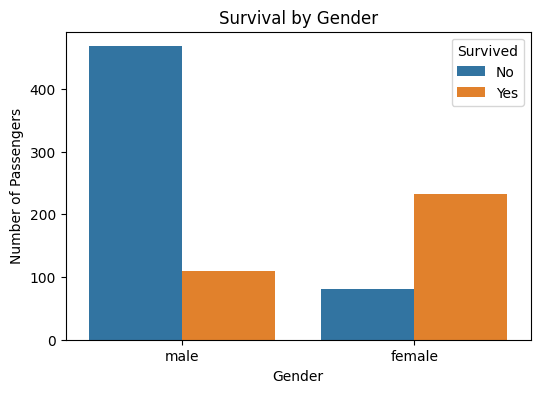

In [9]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=titanic_clean,
    x="sex",
    hue="survived"
)

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["No", "Yes"])
plt.show()

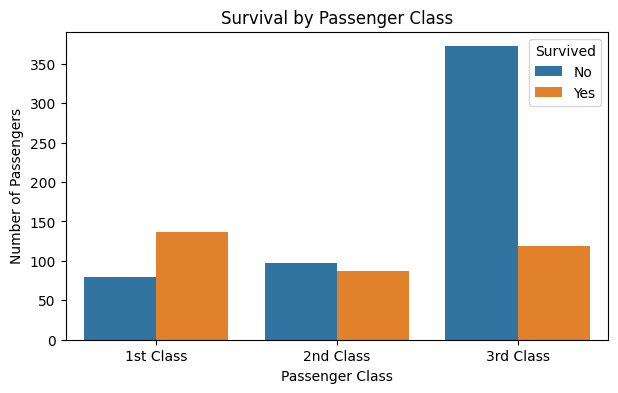

In [10]:
plt.figure(figsize=(7, 4))

sns.countplot(
    data=titanic_clean,
    x="pclass",
    hue="survived"
)

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.xticks([0, 1, 2], ["1st Class", "2nd Class", "3rd Class"])
plt.legend(title="Survived", labels=["No", "Yes"])
plt.show()

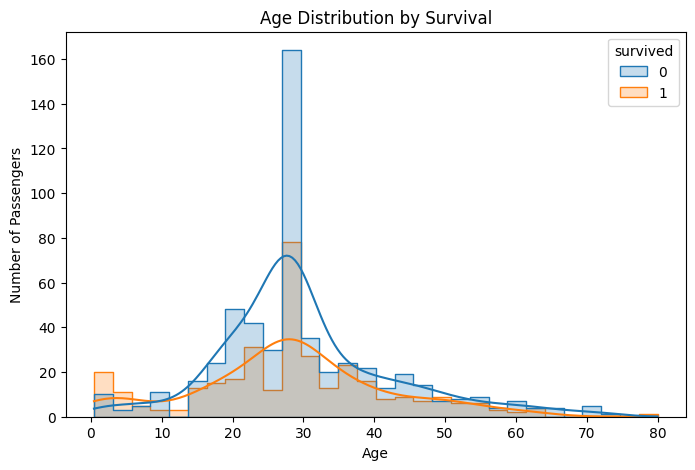

In [11]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=titanic_clean,
    x="age",
    hue="survived",
    bins=30,
    kde=True,
    element="step"
)

plt.title("Age Distribution by Survival")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

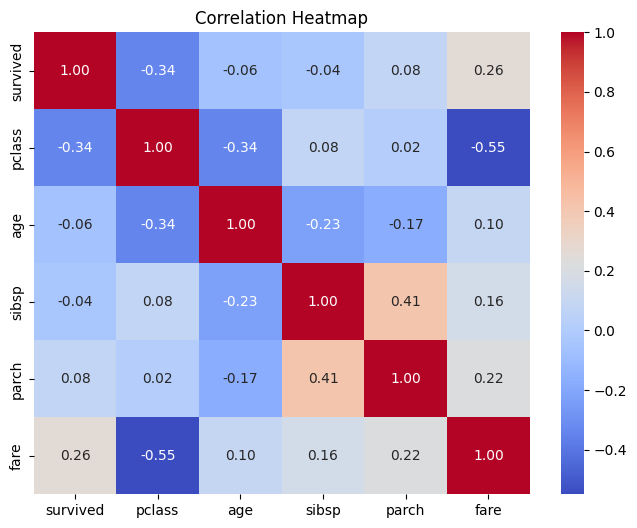

In [12]:
plt.figure(figsize=(8, 6))

correlation = titanic_clean[
    ["survived", "pclass", "age", "sibsp", "parch", "fare"]
].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [13]:
gender_survival_rate = titanic_clean.groupby("sex")["survived"].mean() * 100

gender_survival_rate

sex
female    74.203822
male      18.890815
Name: survived, dtype: float64

In [14]:
class_survival_rate = titanic_clean.groupby("pclass")["survived"].mean() * 100

class_survival_rate

pclass
1    62.962963
2    47.282609
3    24.236253
Name: survived, dtype: float64

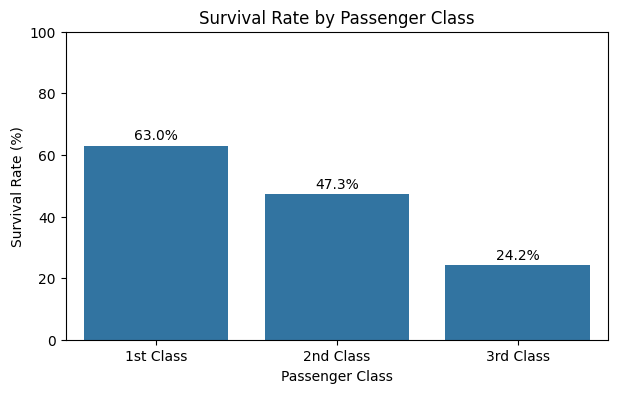

In [15]:
plt.figure(figsize=(7, 4))

sns.barplot(
    x=class_survival_rate.index,
    y=class_survival_rate.values
)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")
plt.xticks([0, 1, 2], ["1st Class", "2nd Class", "3rd Class"])
plt.ylim(0, 100)

for i, rate in enumerate(class_survival_rate.values):
    plt.text(i, rate + 2, f"{rate:.1f}%", ha="center")

plt.show()

In [16]:
gender_class_survival = titanic_clean.pivot_table(
    values="survived",
    index="pclass",
    columns="sex",
    aggfunc="mean"
) * 100

gender_class_survival

sex,female,male
pclass,,
1,96.808511,36.885246
2,92.105263,15.740741
3,50.000000,13.544669


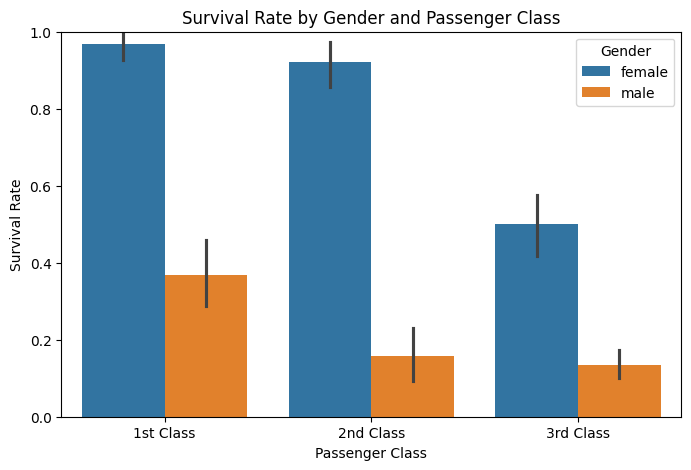

In [17]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=titanic_clean,
    x="pclass",
    y="survived",
    hue="sex",
    estimator="mean"
)

plt.title("Survival Rate by Gender and Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.xticks([0, 1, 2], ["1st Class", "2nd Class", "3rd Class"])
plt.ylim(0, 1)

plt.legend(title="Gender")
plt.show()


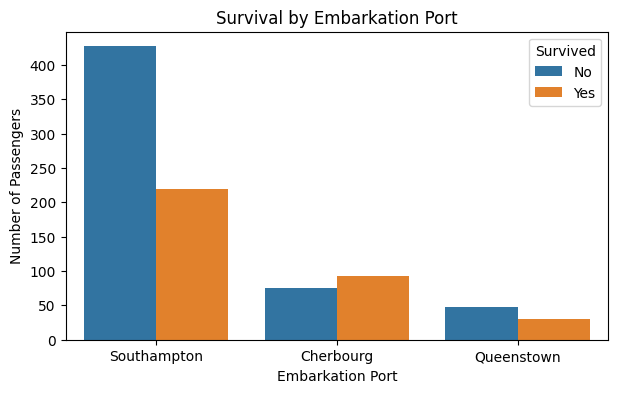

In [18]:
plt.figure(figsize=(7, 4))

sns.countplot(
    data=titanic_clean,
    x="embark_town",
    hue="survived"
)

plt.title("Survival by Embarkation Port")
plt.xlabel("Embarkation Port")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["No", "Yes"])
plt.show()

In [19]:
embark_survival_rate = (
    titanic_clean.groupby("embark_town")["survived"].mean() * 100
)

embark_survival_rate

embark_town
Cherbourg      55.357143
Queenstown     38.961039
Southampton    33.900929
Name: survived, dtype: float64

In [20]:
titanic_clean.to_csv("titanic_clean.csv", index=False)

print("Cleaned Titanic dataset saved successfully!")

Cleaned Titanic dataset saved successfully!


In [21]:
import os

print(os.path.exists("titanic_clean.csv"))

True


In [22]:
titanic_clean

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,Southampton,yes,True
888,0,3,female,28.0,1,2,23.4500,S,Third,woman,False,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,Cherbourg,yes,True


# Part B: Machine Learning

## 1. Train-Test Split and Preprocessing

In [23]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [24]:
df = pd.read_csv("titanic_clean.csv")

print("Dataset shape:", df.shape)
display(df.head())
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (891, 14)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True



Columns:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone']


In [25]:
y = df["survived"]
X = df.drop(
    columns=[
        "survived",
        "alive",
        "adult_male",
        "alone",
        "class",
        "who",
        "embark_town"
    ]
)

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:")
print(X.columns.tolist())

Feature shape: (891, 7)
Target shape: (891,)

Feature columns:
['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training features: (712, 7)
Testing features: (179, 7)

Training target distribution:
survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64

Testing target distribution:
survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64


In [27]:
numeric_features = ["pclass", "age", "sibsp", "parch", "fare"]
categorical_features = ["sex", "embarked"]
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)
print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [28]:
from sklearn.linear_model import LogisticRegression
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)
logistic_pipeline.fit(X_train, y_train)
print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [29]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(
            random_state=42,
            max_depth=5
        ))
    ]
)

decision_tree_pipeline.fit(X_train, y_train)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


In [30]:
from sklearn.ensemble import RandomForestClassifier

random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ))
    ]
)

random_forest_pipeline.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.



Logistic Regression
Confusion Matrix:
[[98 12]
 [23 46]]


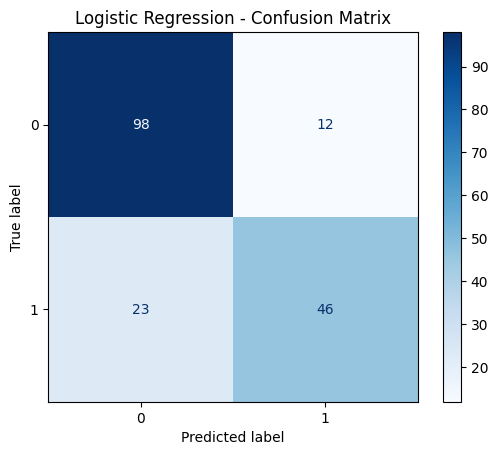


Decision Tree
Confusion Matrix:
[[97 13]
 [29 40]]


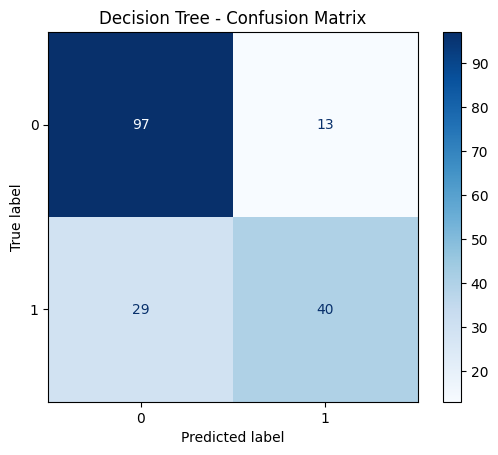


Random Forest
Confusion Matrix:
[[99 11]
 [21 48]]


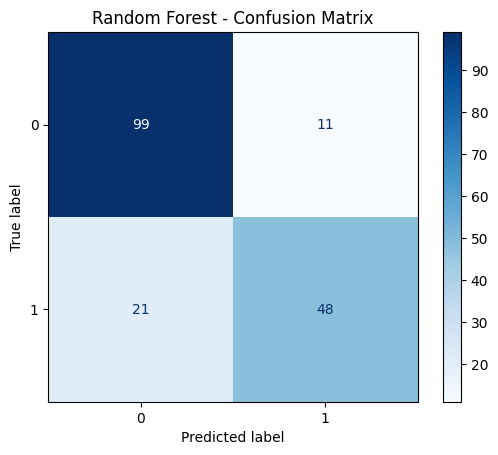


Model Comparison:


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8045,0.7931,0.6667,0.7244,0.8445
1,Decision Tree,0.7654,0.7547,0.5797,0.6557,0.7971
2,Random Forest,0.8212,0.8136,0.6957,0.7500,0.8272


In [31]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

models = {
    "Logistic Regression": logistic_pipeline,
    "Decision Tree": decision_tree_pipeline,
    "Random Forest": random_forest_pipeline
}

results = []

for model_name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

    print(f"\n{model_name}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        cmap="Blues"
    )
    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

comparison_df = pd.DataFrame(results)

print("\nModel Comparison:")
display(comparison_df.round(4))

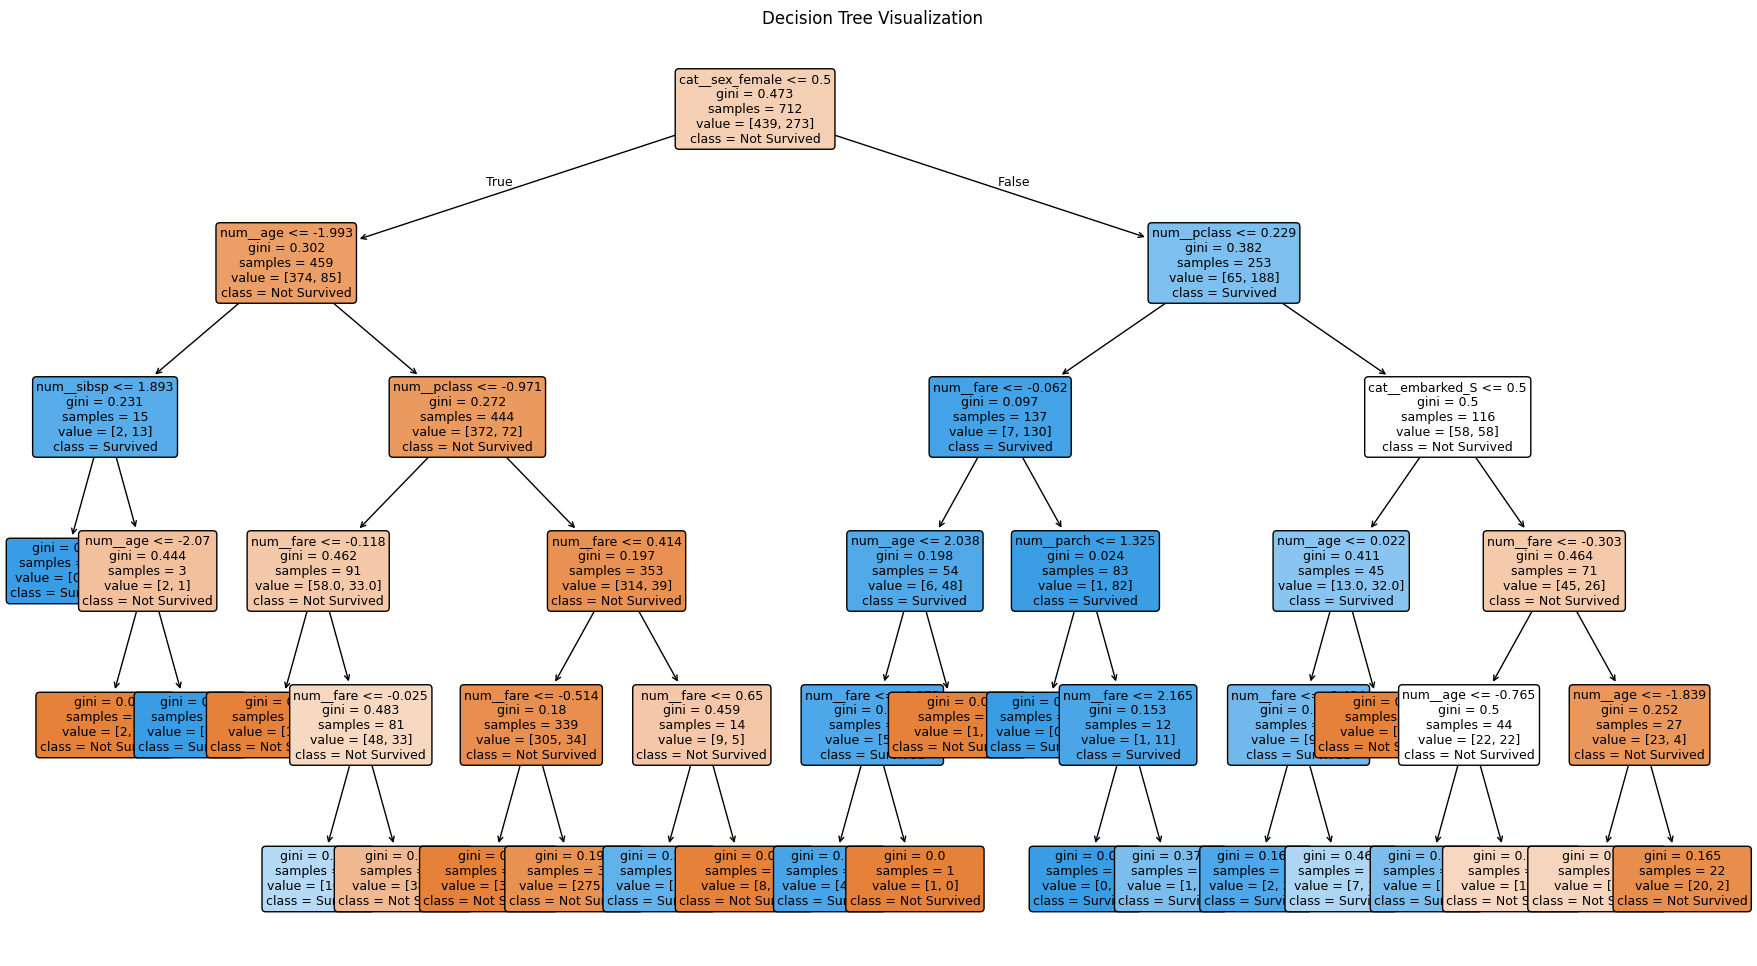

In [32]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
tree_model = decision_tree_pipeline.named_steps["classifier"]
feature_names = (
    decision_tree_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

plt.figure(figsize=(22, 12))

plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=["Not Survived", "Survived"],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Decision Tree Visualization")
plt.show()

In [33]:
class_counts = y.value_counts()
class_percentages = y.value_counts(normalize=True) * 100

print("Class counts:")
print(class_counts)

print("\nClass percentages:")
print(class_percentages.round(2))
majority_class = y_train.mode()[0]
baseline_predictions = np.full(len(y_test), majority_class)

print("\nMajority class:", majority_class)
print(
    "Baseline accuracy:",
    round(accuracy_score(y_test, baseline_predictions), 4)
)

Class counts:
survived
0    549
1    342
Name: count, dtype: int64

Class percentages:
survived
0    61.62
1    38.38
Name: proportion, dtype: float64

Majority class: 0
Baseline accuracy: 0.6145


In [34]:
balanced_models = {
    "Balanced Logistic Regression": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", LogisticRegression(
                max_iter=1000,
                class_weight="balanced"
            ))
        ]
    ),

    "Balanced Decision Tree": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", DecisionTreeClassifier(
                random_state=42,
                max_depth=5,
                class_weight="balanced"
            ))
        ]
    ),

    "Balanced Random Forest": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", RandomForestClassifier(
                n_estimators=100,
                random_state=42,
                class_weight="balanced"
            ))
        ]
    )
}

balanced_results = []

for model_name, model in balanced_models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    balanced_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

balanced_comparison_df = pd.DataFrame(balanced_results)

print("Class-weight-balanced model comparison:")
display(balanced_comparison_df.round(4))

Class-weight-balanced model comparison:


,Model,Accuracy,Precision,Recall,F1 Score
0,Balanced Logistic Regression,0.8045,0.7297,0.7826,0.7552
1,Balanced Decision Tree,0.7765,0.7377,0.6522,0.6923
2,Balanced Random Forest,0.8045,0.7833,0.6812,0.7287


In [37]:
!python -m pip install imbalanced-learn

     -------------------------------------- 258.3/258.3 KB 3.2 MB/s eta 0:00:00


You should consider upgrading via the 'c:\Users\B.HARIKA\zepto-data-ai-platform\.venv\Scripts\python.exe -m pip install --upgrade pip' command.


In [38]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
smote_pipeline = ImbPipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

smote_pipeline.fit(X_train, y_train)

y_pred_smote = smote_pipeline.predict(X_test)

smote_results = pd.DataFrame([{
    "Model": "Logistic Regression + SMOTE",
    "Accuracy": accuracy_score(y_test, y_pred_smote),
    "Precision": precision_score(y_test, y_pred_smote),
    "Recall": recall_score(y_test, y_pred_smote),
    "F1 Score": f1_score(y_test, y_pred_smote)
}])

print("SMOTE model results:")
display(smote_results.round(4))

SMOTE model results:


c:\Users\B.HARIKA\zepto-data-ai-platform\.venv\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression + SMOTE,0.8101,0.7397,0.7826,0.7606


In [39]:
original_results = comparison_df[
    ["Model", "Accuracy", "Precision", "Recall", "F1 Score"]
].copy()
imbalance_comparison = pd.concat(
    [
        original_results,
        balanced_comparison_df,
        smote_results
    ],
    ignore_index=True
)
print("Imbalance handling comparison:")
display(imbalance_comparison.round(4))

Imbalance handling comparison:


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8045,0.7931,0.6667,0.7244
1,Decision Tree,0.7654,0.7547,0.5797,0.6557
2,Random Forest,0.8212,0.8136,0.6957,0.7500
3,Balanced Logistic Regression,0.8045,0.7297,0.7826,0.7552
4,Balanced Decision Tree,0.7765,0.7377,0.6522,0.6923
5,Balanced Random Forest,0.8045,0.7833,0.6812,0.7287
6,Logistic Regression + SMOTE,0.8101,0.7397,0.7826,0.7606


### Imbalance Handling Interpretation

The Titanic dataset is moderately imbalanced, with 61.62% non-survivors and 38.38% survivors. The majority-class baseline accuracy is 61.45%, and all trained models perform better than this baseline.

The original Random Forest achieved the highest accuracy of 82.12%, while Logistic Regression with SMOTE achieved the highest F1-score of 0.7606 and recall of 0.7826 among the tested approaches. SMOTE improved the model's ability to identify survivors, although its precision decreased slightly.

Therefore, Logistic Regression with SMOTE is useful when identifying as many survivors as possible is important. The original Random Forest is preferable when overall accuracy and precision are prioritized.

In [40]:
from sklearn.model_selection import GridSearchCV
tuning_rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            random_state=42,
            oob_score=True,
            bootstrap=True
        ))
    ]
)
param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 5, 10],
    "classifier__max_features": ["sqrt", "log2"]
}

grid_search = GridSearchCV(
    estimator=tuning_rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation F1-score:")
print(round(grid_search.best_score_, 4))

best_rf_pipeline = grid_search.best_estimator_

print("\nOOB score:")
print(round(
    best_rf_pipeline.named_steps["classifier"].oob_score_,
    4
))

Best parameters:
{'classifier__max_depth': 10, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 100}

Best cross-validation F1-score:
0.7452

OOB score:
0.8062


### Random Forest Hyperparameter Tuning Interpretation

GridSearchCV was used with 5-fold cross-validation to tune the Random Forest model. The best configuration used 100 trees, a maximum tree depth of 10, and the square-root feature selection strategy.

The best cross-validation F1-score was 0.7452. The out-of-bag score of the tuned Random Forest was 0.8062, indicating good performance on samples not used in the bootstrap training process.

The tuned model will be evaluated on the test set and compared with the earlier Random Forest model.

Tuned Random Forest results:


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Tuned Random Forest,0.8212,0.8246,0.6812,0.746,0.8424



Confusion Matrix:
[[100  10]
 [ 22  47]]


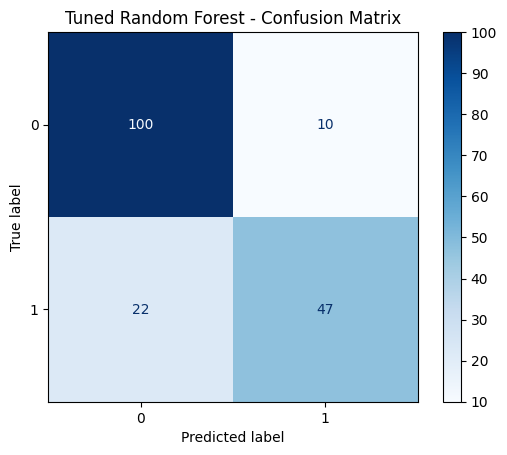

In [41]:
y_pred_tuned = best_rf_pipeline.predict(X_test)
y_prob_tuned = best_rf_pipeline.predict_proba(X_test)[:, 1]

tuned_rf_results = pd.DataFrame([{
    "Model": "Tuned Random Forest",
    "Accuracy": accuracy_score(y_test, y_pred_tuned),
    "Precision": precision_score(y_test, y_pred_tuned),
    "Recall": recall_score(y_test, y_pred_tuned),
    "F1 Score": f1_score(y_test, y_pred_tuned),
    "ROC-AUC": roc_auc_score(y_test, y_prob_tuned)
}])

print("Tuned Random Forest results:")
display(tuned_rf_results.round(4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_tuned,
    cmap="Blues"
)

plt.title("Tuned Random Forest - Confusion Matrix")
plt.show()

### Tuned Random Forest Evaluation Interpretation

The tuned Random Forest correctly classified 147 out of 179 test passengers. It correctly predicted 100 non-survivors and 47 survivors.

The model produced 10 false positives and 22 false negatives. This means that it predicted survival incorrectly for 10 passengers and failed to identify 22 passengers who actually survived.

The confusion matrix shows that the model performs well overall, but identifying additional survivors remains an area for improvement.

## 2. Regression: Predicting Passenger Fare

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
y_reg = df["fare"]
X_reg = df.drop(columns=["fare"])
X_reg = X_reg.drop(
    columns=[
        "survived",
        "alive",
        "adult_male",
        "alone",
        "class",
        "who",
        "embark_town"
    ]
)
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

numeric_reg_features = ["pclass", "age", "sibsp", "parch"]
categorical_reg_features = ["sex", "embarked"]

numeric_reg_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_reg_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

reg_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_reg_transformer, numeric_reg_features),
        ("cat", categorical_reg_transformer, categorical_reg_features)
    ]
)

regression_pipeline = Pipeline(
    steps=[
        ("preprocessor", reg_preprocessor),
        ("regressor", LinearRegression())
    ]
)

regression_pipeline.fit(X_reg_train, y_reg_train)

print("Regression data prepared and model trained successfully.")
print("Training shape:", X_reg_train.shape)
print("Testing shape:", X_reg_test.shape)

Regression data prepared and model trained successfully.
Training shape: (712, 6)
Testing shape: (179, 6)


In [43]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
y_reg_pred = regression_pipeline.predict(X_reg_test)
mae = mean_absolute_error(y_reg_test, y_reg_pred)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
r2 = r2_score(y_reg_test, y_reg_pred)
n = X_reg_test.shape[0]
p = X_reg_test.shape[1]

adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print("Regression Evaluation Results")
print("MAE:", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R² Score:", round(r2, 4))
print("Adjusted R²:", round(adjusted_r2, 4))

Regression Evaluation Results
MAE: 20.8094
RMSE: 30.4731
R² Score: 0.3999
Adjusted R²: 0.379


### Regression Evaluation Interpretation

The multivariate linear regression model achieved an MAE of 20.8094 and an RMSE of 30.4731. This means that the model's fare predictions have an average absolute error of approximately 20.81 fare units.

The R² score is 0.3999, meaning that the model explains approximately 39.99% of the variation in passenger fares. The adjusted R² score is 0.3790, which is slightly lower after accounting for the number of predictors.

The model provides a moderate prediction of fare, but a considerable amount of variation remains unexplained. This may be because fare is influenced by additional factors such as ticket group size, cabin, and ticket number, which were not included in the model.

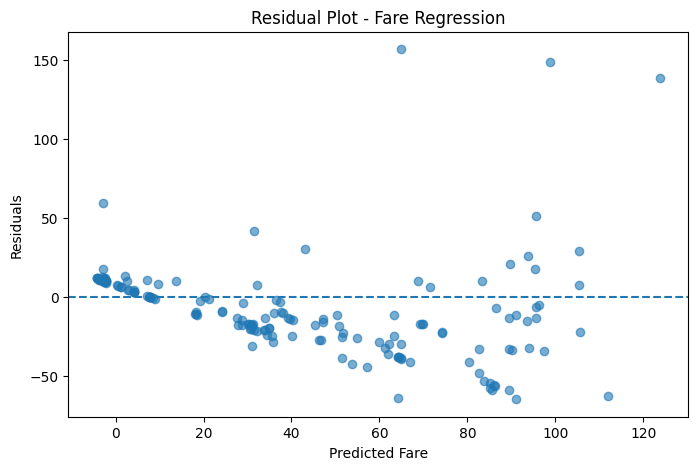

In [44]:
residuals = y_reg_test - y_reg_pred

plt.figure(figsize=(8, 5))

plt.scatter(
    y_reg_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.title("Residual Plot - Fare Regression")
plt.show()

### Residual Plot Interpretation

The residual plot shows that the residuals are not evenly distributed around the zero line. The spread of residuals increases as the predicted fare increases, and several large positive and negative residuals are present.

This pattern suggests possible heteroscedasticity, meaning that the variance of prediction errors is not constant across fare values. The model predicts lower fares more consistently, while higher fares show larger prediction errors.

Therefore, the linear regression model has only moderate predictive performance and may not fully capture the factors influencing passenger fares.

## 3. Final Model Comparison

In [45]:
final_classifier_comparison = pd.concat(
    [
        comparison_df,
        tuned_rf_results
    ],
    ignore_index=True
)

print("Final Classifier Comparison:")
display(final_classifier_comparison.round(4))

final_regression_comparison = pd.DataFrame([{
    "Model": "Multivariate Linear Regression",
    "MAE": mae,
    "RMSE": rmse,
    "R²": r2,
    "Adjusted R²": adjusted_r2
}])

print("\nFinal Regression Comparison:")
display(final_regression_comparison.round(4))

Final Classifier Comparison:


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8045,0.7931,0.6667,0.7244,0.8445
1,Decision Tree,0.7654,0.7547,0.5797,0.6557,0.7971
2,Random Forest,0.8212,0.8136,0.6957,0.7500,0.8272
3,Tuned Random Forest,0.8212,0.8246,0.6812,0.7460,0.8424



Final Regression Comparison:


,Model,MAE,RMSE,R²,Adjusted R²
0,Multivariate Linear Regression,20.8094,30.4731,0.3999,0.379


### Final Recommendation

Random Forest achieved the best overall accuracy of 82.12%. Logistic Regression with SMOTE achieved the highest recall and F1-score among the imbalance-handling approaches. Therefore, Random Forest is recommended for overall performance, while Logistic Regression with SMOTE is useful when identifying more survivors is the priority.

The fare regression model achieved an R² of 0.3999, showing moderate predictive performance.

In [46]:
import joblib
joblib.dump(
    best_rf_pipeline,
    "titanic_final_pipeline.joblib"
)
print("Final pipeline saved successfully.")

Final pipeline saved successfully.


In [47]:
loaded_pipeline = joblib.load("titanic_final_pipeline.joblib")
new_passenger = pd.DataFrame([{
    "pclass": 3,
    "sex": "male",
    "age": 22,
    "sibsp": 1,
    "parch": 0,
    "fare": 7.25,
    "embarked": "S"
}])
prediction = loaded_pipeline.predict(new_passenger)
probability = loaded_pipeline.predict_proba(new_passenger)[0][1]

print("Predicted survival:", prediction[0])
print("Survival probability:", round(probability, 4))

if prediction[0] == 1:
    print("Result: Passenger is predicted to survive.")
else:
    print("Result: Passenger is predicted not to survive.")

Predicted survival: 0
Survival probability: 0.112
Result: Passenger is predicted not to survive.
